In [1]:
import numpy as np, matplotlib.pyplot as plt, time
from astropy.table import Table
from pathlib import Path

# Import nuGundam related classes
from nugundam import (pcf, read_result, ProjectedAutoConfig, ProjectedAutoCountsConfig,
     ProjectedBinning, ProjectedGridSpec, ProjectedCatalogColumns, plot_jk_regions,
     WeightSpec, BootstrapSpec, JackknifeSpec, SplitRandomSpec, DistanceSpec)

# Projected correlations with nuGundam
-----------------
This notebook is a quick tutorial of how to calculate autocorrelations in projected space

## Read data

In [2]:
# Adjust BASEPATH if needed
BASEPATH = Path('./data/')
DATAFILE = BASEPATH / 'DATA.fits'
RANDFILE = BASEPATH / 'RAND.fits'

data = Table.read(DATAFILE)
rans = Table.read(RANDFILE)

## 1. Create configuration

First we need to create a configuration object which is designed to hold several specifications of the computation to perform. In this case it corresponds to an angular auto-correlation so we use a config object of type ``ProjectedAutoConfig``. This is where you specify the estimator chosen, the binning for counting, the counting grid, the name of relevant columns in the datasets, and various other parameters.

In [3]:
config1 = ProjectedAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data=ProjectedCatalogColumns(ra="ra_coord", dec="dec_coord", redshift='z_spec'),
    columns_random=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    # Set number of threads
    nthreads = 4,
    # Specify binning in rp-direction > number_of_bins, minimum separation [Mpc/h], bin size (in dex if logsep=True)
    # Specify binning in pi-direction > number_of_bins, bin size
    binning=ProjectedBinning.from_binsize(
        nsepp=28, seppmin=0.02, dsepp=0.12, logsepp=True,
        nsepv=4, dsepv=10.0),
    # Choose counting grid and ordering 
    grid = ProjectedGridSpec(autogrid=True, pxorder="natural"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="unweighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
    # Enable distance calculation module
    distance=DistanceSpec(calcdist=True, h0=100., omegam=0.25, omegal=0.75)
)

## 2. Run correlation

Pass the data, randoms and configuration to ``pcf`` to perform a correlation run and obtain a result object, in this case of type ``ProjectedCorrelationResult``. Once finished, it will contain all the counts, bins, correlation function, errors and relevant metadata

In [4]:
ti = time.time()
result1 = pcf(data, rans, config1)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[pcf] preparing data and randoms
[pcf] counting DD / RR / DR with estimator=LS


[pcf] estimating correlation
[pcf] done
elapsed time [s]: 10.126


In [5]:
result1.wp

array([1305.70764767, 1225.38077123,  942.26153824,  691.17616689,
        631.29512707,  563.47308314,  428.61594807,  356.67942956,
        304.28075525,  256.33004187,  214.19359567,  172.23599087,
        134.98370348,  102.15112805,   78.53092003,   60.14175673,
         46.22836913,   36.85014231,   30.82228711,   25.77231746,
         20.80598701,   17.37083041,   14.55618111,   11.86360486,
          9.9546242 ,    8.40035094,    5.92237689,    3.00535769])

In [6]:
result1.counts.dd

array([[6.9800000e+02, 4.4000000e+01, 1.9000000e+01, 1.4000000e+01],
       [9.9400000e+02, 8.6000000e+01, 2.2000000e+01, 1.9000000e+01],
       [1.3770000e+03, 1.5800000e+02, 4.7000000e+01, 3.4000000e+01],
       [2.0290000e+03, 2.3700000e+02, 9.6000000e+01, 4.9000000e+01],
       [2.9390000e+03, 4.0100000e+02, 1.3200000e+02, 1.0100000e+02],
       [4.2410000e+03, 6.5500000e+02, 2.4200000e+02, 1.5800000e+02],
       [6.0300000e+03, 1.1660000e+03, 4.4300000e+02, 2.6200000e+02],
       [8.6340000e+03, 1.8490000e+03, 7.1200000e+02, 4.3400000e+02],
       [1.2387000e+04, 2.9850000e+03, 1.2260000e+03, 8.2000000e+02],
       [1.8171000e+04, 4.7930000e+03, 2.1140000e+03, 1.3090000e+03],
       [2.6333000e+04, 7.5620000e+03, 3.4800000e+03, 2.3110000e+03],
       [3.8036000e+04, 1.1543000e+04, 5.6230000e+03, 3.9120000e+03],
       [5.3870000e+04, 1.6978000e+04, 9.3080000e+03, 6.6220000e+03],
       [7.5611000e+04, 2.5963000e+04, 1.4824000e+04, 1.1098000e+04],
       [1.0755300e+05, 3.9787000e+

In [7]:
result1.rp_centers

array([2.29630724e-02, 3.02712250e-02, 3.99052463e-02, 5.26053598e-02,
       6.93473701e-02, 9.14176379e-02, 1.20511917e-01, 1.58865647e-01,
       2.09425710e-01, 2.76076853e-01, 3.63940172e-01, 4.79766584e-01,
       6.32455532e-01, 8.33738767e-01, 1.09908175e+00, 1.44887192e+00,
       1.90998517e+00, 2.51785082e+00, 3.31917381e+00, 4.37552325e+00,
       5.76806301e+00, 7.60378793e+00, 1.00237447e+01, 1.32138690e+01,
       1.74192718e+01, 2.29630724e+01, 3.02712250e+01, 3.99052463e+01])

The correlation function can be plotted directly from its result object

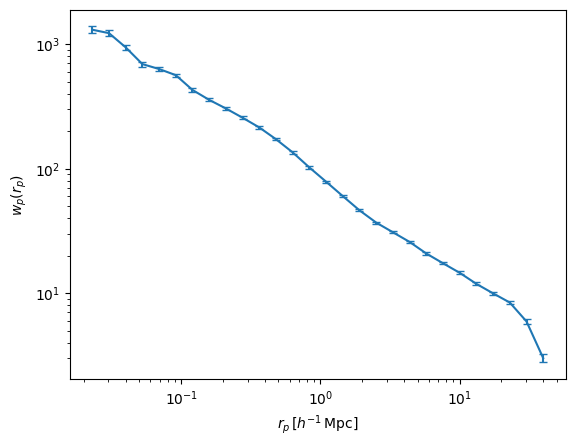

In [8]:
result1.plot();

## 3. Save/read results

Result objects are designed to contain all the information of a given run, so they are the natural way of persisting correlations to disk. You can use the ``save`` or ``save_result`` method  

In [10]:
result1.save('result1.gres')

To read results back use ``read_result()``

In [11]:
result1_readback = read_result('result1.gres')
result1_readback.counts.rr

array([[8.10000000e+01, 7.50000000e+01, 7.20000000e+01, 4.80000000e+01],
       [1.23000000e+02, 1.25000000e+02, 1.05000000e+02, 1.07000000e+02],
       [2.30000000e+02, 2.45000000e+02, 2.22000000e+02, 1.72000000e+02],
       [4.71000000e+02, 4.20000000e+02, 3.74000000e+02, 3.27000000e+02],
       [7.53000000e+02, 6.79000000e+02, 6.56000000e+02, 5.56000000e+02],
       [1.19300000e+03, 1.18000000e+03, 1.10800000e+03, 9.29000000e+02],
       [2.35200000e+03, 2.10600000e+03, 1.82400000e+03, 1.68300000e+03],
       [4.05400000e+03, 3.62400000e+03, 3.20500000e+03, 2.97800000e+03],
       [6.91600000e+03, 6.06200000e+03, 5.65400000e+03, 4.96700000e+03],
       [1.18270000e+04, 1.07850000e+04, 9.66000000e+03, 8.76700000e+03],
       [2.05280000e+04, 1.88200000e+04, 1.70940000e+04, 1.53430000e+04],
       [3.59920000e+04, 3.27270000e+04, 2.95280000e+04, 2.65380000e+04],
       [6.21000000e+04, 5.66020000e+04, 5.13740000e+04, 4.58700000e+04],
       [1.07840000e+05, 9.79970000e+04, 8.87310000e

In [12]:
result1.to_ascii('result1.ascii')

## 4. Run a weighted correlation

In [6]:
# Inject some artifical non-unitary weights
data['weight'] = 1.0
data['weight'][0:40] = 2.4
data['weight'][900:980] = 2.8
data['weight'][4900:4500] = 2.3
data['weight'][23000:23500] = 3.5
data['weight'][35000:44000] = 0.1
data['weight'][64000:69000] = 0.2

In [7]:
config2 = ProjectedAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data=ProjectedCatalogColumns(ra="ra_coord", dec="dec_coord", redshift='z_spec', weight='weight'),
    columns_random=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    # Set number of threads
    nthreads = 4,
    # Specify binning in rp-direction > number_of_bins, minimum separation [Mpc/h], bin size (in dex if logsep=True)
    # Specify binning in pi-direction > number_of_bins, bin size
    binning=ProjectedBinning.from_binsize(
        nsepp=28, seppmin=0.02, dsepp=0.12, logsepp=True,
        nsepv=4, dsepv=10.0),
    # Choose counting grid and ordering 
    grid = ProjectedGridSpec(autogrid=True, pxorder="natural"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="weighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
    # Enable distance calculation module
    distance=DistanceSpec(calcdist=True, h0=100., omegam=0.25, omegal=0.75)
)

In [8]:
ti = time.time()
result2 = pcf(data, rans, config2)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[pcf] preparing data and randoms
[pcf] counting DD / RR / DR with estimator=LS


[pcf] estimating correlation
[pcf] done
elapsed time [s]: 9.964


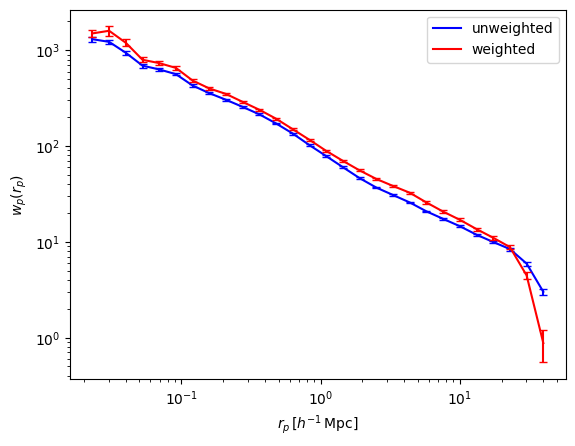

In [9]:
result1.plot(color='b', label='unweighted')
result2.plot(color='r', label='weighted')
plt.legend();

## 5. Bootstrap and Jackkinfe Errors

nuGundam supports two models to estimate errors: 

* **Boostrap** : the error is estimated by generating many resampled versions of the data catalog, drawn with replacement from the original sample. The correlation function is evaluated for each realization, and the dispersion across the bootstrap results is used to estimate per-bin uncertainties. This provides a practical, data-driven way to quantify statistical errors without requiring external mock catalogs. To use it, enable ``BootstrapSpec`` in the configuration.
* **Jackknife** : the survey area is divided into a set of spatial regions and the correlation function is recomputed repeatedly, each time leaving out one region. The variation among these leave-one-region-out measurements is then used to estimate the uncertainty and covariance of the correlation function. Because the resampling is performed over spatial subregions, jackknife errors are especially useful for capturing the impact of large-scale fluctuations within the observed footprint. To use it, enable ``JackknifeSpec`` in the configuration.

In the first two correlation above we already calculated bootrap errors. Below we see an example of the jackknife technique.

In [10]:
config_jack = ProjectedAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data=ProjectedCatalogColumns(ra="ra_coord", dec="dec_coord", redshift='z_spec'),
    columns_random=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    # Set number of threads
    nthreads = 4,
    # Specify binning in rp-direction > number_of_bins, minimum separation [Mpc/h], bin size (in dex if logsep=True)
    # Specify binning in pi-direction > number_of_bins, bin size
    binning=ProjectedBinning.from_binsize(
        nsepp=28, seppmin=0.02, dsepp=0.12, logsepp=True,
        nsepv=4, dsepv=10.0),
    # Choose counting grid and ordering 
    grid = ProjectedGridSpec(autogrid=True, pxorder="natural"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="unweighted"),
    # Enable jackknife error module
    jackknife=JackknifeSpec(enabled=True, nregions=32, return_cov=True, return_realizations=False),
    # Enable distance calculation module
    distance=DistanceSpec(calcdist=True, h0=100., omegam=0.25, omegal=0.75)
)

In [11]:
ti = time.time()
result1_jack = pcf(data, rans, config_jack)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[pcf] preparing data and randoms
[pcf] counting DD / RR / DR with estimator=LS


[pcf] estimating correlation
[pcf] assembling jackknife covariance
[pcf] done
elapsed time [s]: 10.240


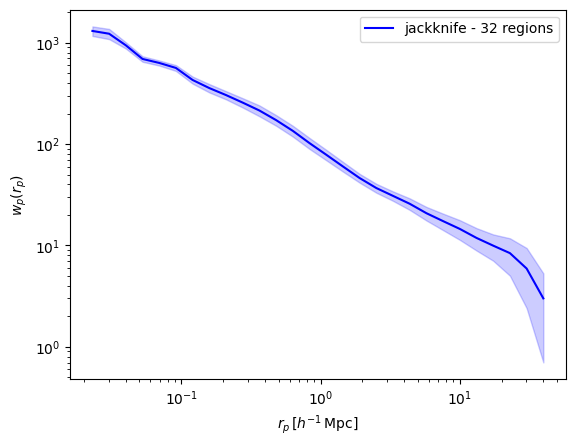

In [12]:
result1_jack.plot(color='b', errors='band', label='jackknife - 32 regions')
plt.legend();

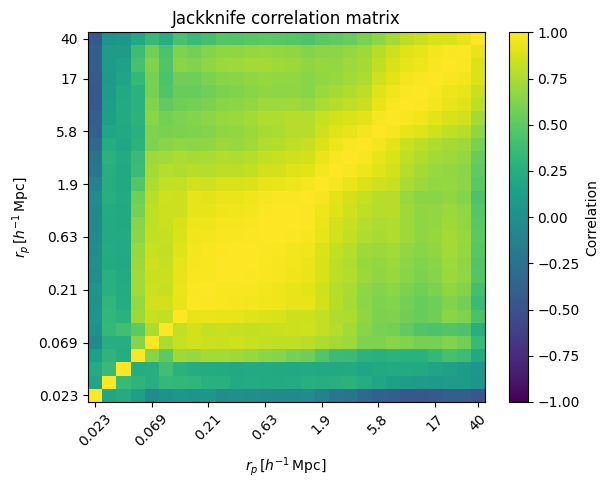

In [21]:
result1_jack.plot_corr_matrix();

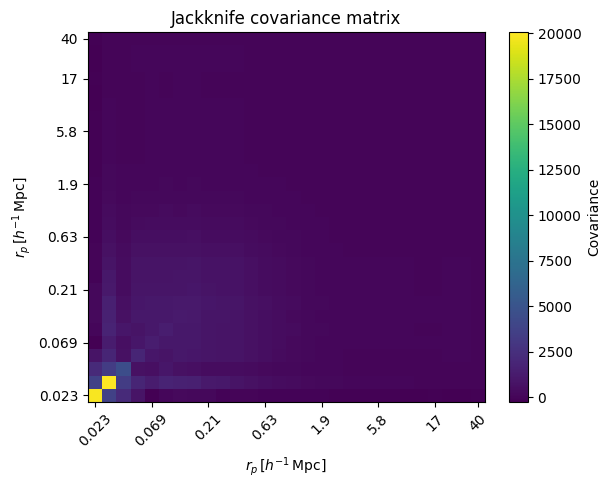

In [22]:
result1_jack.plot_cov_matrix();

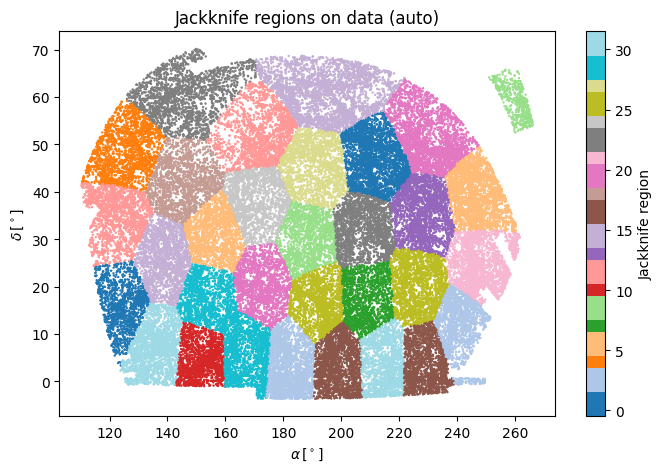

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_jk_regions(data, rans, config_jack, catalog='data', ax=ax);

It is easy to check the statistics of the jackknife regions that are built automatically by nuGundam

In [24]:
from nugundam.projected.prepare import prepare_projected_auto
data_p, rand_p, meta = prepare_projected_auto(data, rans, config_jack)
nreg = meta["jk_nregions"]

print("nregions =", nreg)
print("region source =", meta["jk_region_source"])

ndata_reg = np.bincount(data_p.region_id, minlength=nreg)
nrand_reg = np.bincount(rand_p.region_id, minlength=nreg)

print("data per region   :", ndata_reg)
print("random per region :", nrand_reg)

nregions = 32
region source = auto
data per region   : [4615 1649 2392 3523 2743 2263 3297 1900  663 1878 2642 2542 2256 3861
 4284 2393 2580 2907 2207 2202 3993 3345 2730 2488 2130 2496 2637 2230
 2374 1870 3143 2150]
random per region : [6895 7487 6616 7554 7119 6294 6919 7092 1767 6910 5842 7661 7704 7779
 8392 7871 6594 6928 7937 8145 7272 7675 7795 7267 7048 7045 7997 7144
 7268 6815 7720 6784]


## 6. Spliting randoms

In many correlation-function measurements, the runtime is dominated by the random–random (RR) counts. When the random catalog is very large, nuGundam can speed up the calculation through a random-split strategy: the full random sample is divided into several smaller, spatially matched subsamples R_s, the counts are computed in each subsample, and the partial results are then combined with the proper normalization to reconstruct the full RR term. This method has been shown to preserve the bias and variance properties of the Landy–Szalay estimator at medium and large scales ([Keihänen et al. 2019](https://ui.adsabs.harvard.edu/abs/2019A%26A...631A..73K/abstract)), while causing only a minor impact on the clustering estimate at the smallest scales.

In [13]:
config1_rsplit = ProjectedAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data=ProjectedCatalogColumns(ra="ra_coord", dec="dec_coord", redshift='z_spec'),
    columns_random=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    # Set number of threads
    nthreads = 4,
    # Specify binning in rp-direction > number_of_bins, minimum separation [Mpc/h], bin size (in dex if logsep=True)
    # Specify binning in pi-direction > number_of_bins, bin size
    binning=ProjectedBinning.from_binsize(
        nsepp=28, seppmin=0.02, dsepp=0.12, logsepp=True,
        nsepv=4, dsepv=10.0),
    # Choose counting grid and ordering 
    grid = ProjectedGridSpec(autogrid=True, pxorder="natural"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="unweighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
    # Enable distance calculation module
    distance = DistanceSpec(calcdist=True, h0=100., omegam=0.25, omegal=0.75),
    # Enable split random module > mode can be match_data, nchunks or chunk_size
    split_random = SplitRandomSpec(enabled=True, mode="match_data", seed=12345)
)

In [14]:
ti = time.time()
result1_rsplit = pcf(data, rans, config1_rsplit)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[pcf] preparing data and randoms
[pcf] counting DD / RR / DR with estimator=LS


[pcf] estimating correlation
[pcf] done
elapsed time [s]: 7.692


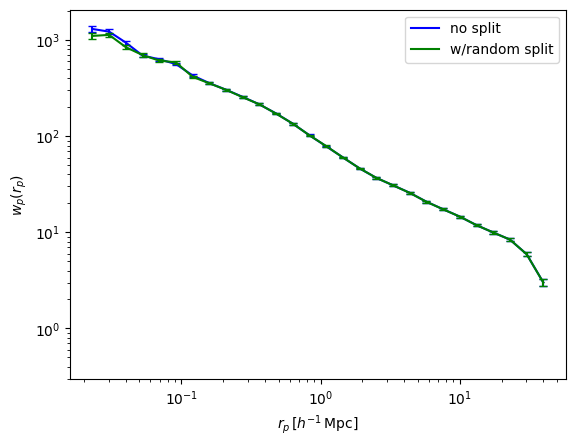

In [16]:
result1.plot(color='b', label='no split')
result1_rsplit.plot(color='g', label='w/random split')
plt.legend();

Note this example is too small (84k data, 227k randoms)to justify the performance gained by using split random. However, when random samples are in the order of millions or hundreds of millions, and, as usual, area much larger compared to data samples, the splitting technique can easily reduce compute time by factors of 5x-10x.